In [11]:
import pandas as pd

salary_df = pd.read_excel("Tab3_zpl_2024.xlsx")  
inflation_df = pd.read_excel("inflation.xlsx")
salary_old_df = pd.read_csv("Tab3_zpl_2000.csv", sep = ';')

In [12]:
salary_df.head()

,Вид деятельности,2017,2018,2019,2020,2021,2022,2023,2024
0,Всего,39167.0,43724.0,47866.8,51344.0,57243.7,65338.3,74854.0,87951.5
1,"сельское, лесное хозяйство, охота, рыболовст...",25671.1,28699.0,31727.6,34770.0,39436.8,46777.0,54158.1,63637.5
2,в том числе:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"растениеводство и животноводство, охота и ...",23529.1,25820.0,28395.8,31058.0,35460.2,41993.7,48840.4,58284.0
4,лесоводство и лесозаготовки,27616.6,32701.0,35426.2,37855.0,42151.8,48327.2,53542.8,62613.4


In [13]:
salary_old_df.head()

,Вид деятельности,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
0,Всего по экономике,2223.0,3240.0,4360.0,5499.0,6740.0,8555.0,10634.0,13593.0,17290.0,18638.0,20952.0,23369.0,26629.0,29792.0,32495.0,34030.0,36709.0
1,"Сельское хозяйство, охота и лесное хозяйство",985.0,1435.0,1876.0,2340.0,3015.0,3646.0,4569.0,6144.0,8475.0,9619.0,10668.0,12464.0,14129.0,15724.0,17724.0,19721.0,21755.0
2,"Рыболовство, рыбоводство",2846.0,3839.0,5031.0,5445.0,7085.0,10234.0,12311.0,14797.0,19499.0,22914.0,23782.0,25940.0,29201.0,32437.0,37062.0,46676.0,54927.0
3,Добыча полезных ископаемых,5940.0,9099.0,11081.0,13912.0,16842.0,19727.0,23145.0,28108.0,33206.0,35363.0,39895.0,45132.0,50401.0,54161.0,58959.0,63695.0,69936.0
4,из нее:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Выбираем: 

1) государственное управление и обеспечение военной безопасности; социальное обеспечение (так как моя ОП)

2) деятельность в области информации и связи (возможный карьерный трек)

3) деятельность финансовая и страховая (близкая отрасль, возможный карьерный трек)

Причем для двух преиодов названия отличаются:

1) Государственное управление и обеспечение военной безопасности; социальное страхование
   
2) Финансовая деятельность
   
3) из них связь

In [14]:
inflation_df = inflation_df[['Год', 'Всего']]
inflation_df.columns = ['year', 'inflation'] 

inflation_df = inflation_df.dropna()
inflation_df['year'] = inflation_df['year'].astype(int)
inflation_df['inflation'] = inflation_df['inflation'].astype(float)

inflation_df.head()

,year,inflation
0,2025,1.23
1,2024,9.51
2,2023,7.42
3,2022,11.92
4,2021,8.39


In [15]:
salary_df = salary_df.dropna(subset=['Вид деятельности'])

selected_sectors = [
    'государственное управление и обеспечение военной безопасности; социальное обеспечение',
    'деятельность в области информации и связи',
    'деятельность финансовая и страховая'
]

salary_df = salary_df[salary_df['Вид деятельности'].str.lower().str.contains('|'.join([s.lower() for s in selected_sectors]))]

salary_long = salary_df.melt(id_vars='Вид деятельности', var_name='year', value_name='salary_nominal')
salary_long['year'] = salary_long['year'].astype(int)
salary_long = salary_long.reset_index(drop=True)

salary_long.head()

,Вид деятельности,year,salary_nominal
0,деятельность в области информации и связи,2017,58811.2
1,деятельность финансовая и страховая,2017,84904.0
2,государственное управление и обеспечение военн...,2017,43499.7
3,деятельность в области информации и связи,2018,66590.0
4,деятельность финансовая и страховая,2018,91070.0


In [22]:
salary_old_df = salary_old_df.dropna(subset=['Вид деятельности'])

selected_old_sectors = [
    'Государственное управление и обеспечение военной безопасности; социальное страхование', 'Финансовая деятельность', 'из них связь']

salary_old_df = salary_old_df[salary_old_df['Вид деятельности'].str.lower().str.contains('|'.join([s.lower() for s in selected_old_sectors]))]

salary_old_long = salary_old_df.melt(id_vars='Вид деятельности', var_name='year', value_name='salary_nominal')
salary_old_long['year'] = salary_old_long['year'].astype(int)
salary_old_long = salary_old_long.reset_index(drop=True)

def mapping (x):
    if x == "Государственное управление и обеспечение военной безопасности; социальное страхование":
        x = "государственное управление и обеспечение военной безопасности; социальное обеспечение"
    elif x =="Финансовая деятельность":
        x = "деятельность финансовая и страховая"
    elif x =="     из них связь":
        x = "деятельность в области информации и связи"
    return x

salary_old_long['Вид деятельности'] = salary_old_long['Вид деятельности'].apply(mapping)

In [23]:
salary_old_long.head()

,Вид деятельности,year,salary_nominal
0,деятельность в области информации и связи,2000,2879.0
1,деятельность финансовая и страховая,2000,5232.0
2,государственное управление и обеспечение военн...,2000,2712.0
3,деятельность в области информации и связи,2001,4131.0
4,деятельность финансовая и страховая,2001,8885.0


In [27]:
combined_salary_df = pd.concat([salary_old_long, salary_long], ignore_index=True)

combined_salary_df = combined_salary_df.drop_duplicates(subset=['Вид деятельности', 'year'])

combined_salary_df = combined_salary_df.sort_values(by=['Вид деятельности', 'year']).reset_index(drop=True)

combined_salary_df.head()

,Вид деятельности,year,salary_nominal
0,государственное управление и обеспечение военн...,2000,2712.0
1,государственное управление и обеспечение военн...,2001,3755.0
2,государственное управление и обеспечение военн...,2002,5200.0
3,государственное управление и обеспечение военн...,2003,6914.0
4,государственное управление и обеспечение военн...,2004,7899.0


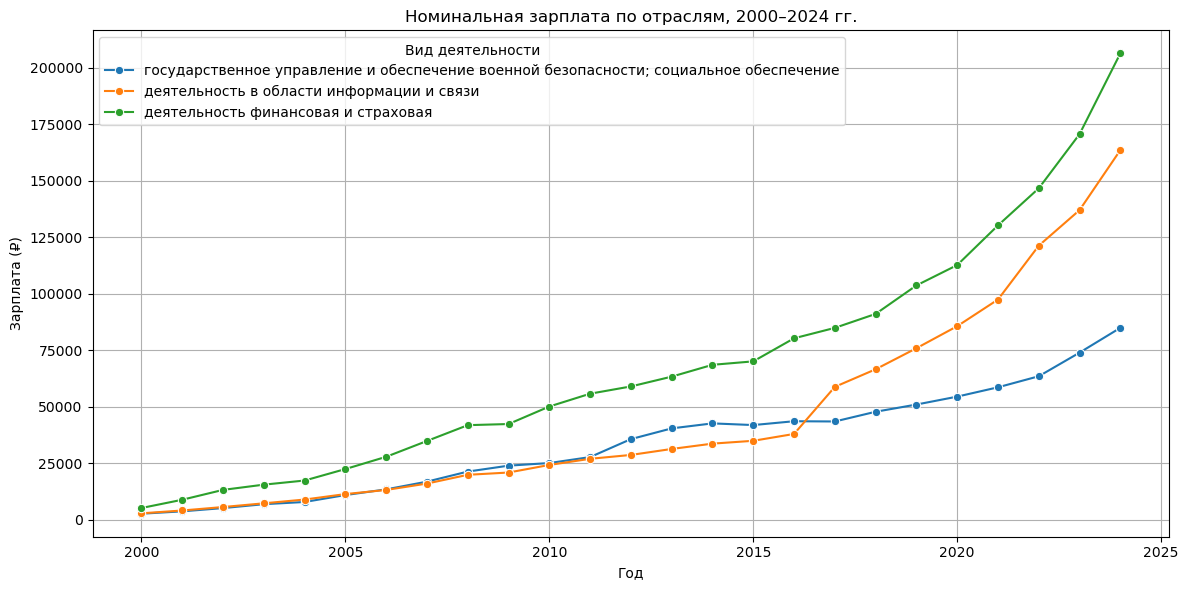

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

selected_sectors = [
    'государственное управление и обеспечение военной безопасности; социальное обеспечение',
    'деятельность в области информации и связи',
    'деятельность финансовая и страховая'
]

plot_df = combined_salary_df[combined_salary_df['Вид деятельности'].isin(selected_sectors)]

plt.figure(figsize=(12, 6))
sns.lineplot(data=plot_df, x='year', y='salary_nominal', hue='Вид деятельности', marker='o')
plt.title('Номинальная зарплата по отраслям, 2000–2024 гг.')
plt.ylabel('Зарплата (₽)')
plt.xlabel('Год')
plt.grid(True)
plt.tight_layout()
plt.show()

# Выводы по номинальным з/п:

В целом по всем трем отраслям видно, что заработные платы росли на протяжении всего периода, хотя рост начинался в одной точке

Медледнее всего росли зарплаты в области госслужбы c пиками в 2011-2012 и ростом с 2020 года (за весь период зарплаты выросли до 70 тысяч)

В рамках области информации и связи зарплаты росли плавно до 2016, затем произошел бурный рост (до 140 тысяч примерно)

В финансовой и страховой отрасли зарплаты росли быстрее всего (с бурным ростом с 2015)

По всем отраслям спада не наблюдалось

In [37]:
inflation_df = inflation_df.sort_values('year')
inflation_df['cumulative_index'] = (1 + inflation_df['inflation'] / 100).cumprod()
inflation_df['deflator'] = inflation_df['cumulative_index'].iloc[-1] / inflation_df['cumulative_index']

merged_df = plot_df.merge(inflation_df[['year', 'deflator']], on='year', how='left')
merged_df['salary_real'] = merged_df['salary_nominal'] * merged_df['deflator']

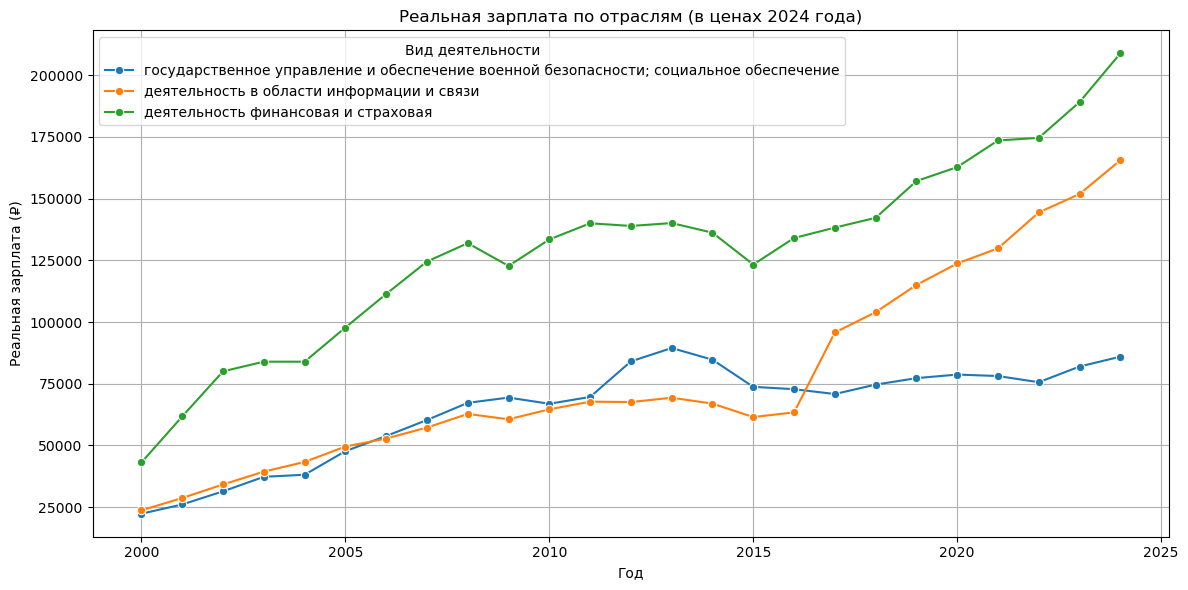

In [38]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=merged_df, x='year', y='salary_real', hue='Вид деятельности', marker='o')
plt.title('Реальная зарплата по отраслям (в ценах 2024 года)')
plt.ylabel('Реальная зарплата (₽)')
plt.xlabel('Год')
plt.grid(True)
plt.tight_layout()
plt.show()

# Выводы по реальным з/п:

В целом по всем трем отраслям видно, что заработные платы все равно росли на протяжении данного периода, хотя неравномерно и со спадами

Медледнее всего росли зарплаты в области госслужбы, причем пик пришелся на 2013, после чего зарплаты начали падать, а затем стагнировали (рост в конце периода вновь восстановился)

В рамках области информации и связи зарплаты росли плавно до 2014, затем произошло падение в 2015-2016, после чего рост возобновился с большими темпами

В финансовой и страховой отрасли зарплаты росли быстрее всего, с падением в 2008-2009 (мировой экономический кризис), в 2015 (санкции) и стагнацией с 2010 по 2014
